In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

RAW = '../data/raw/'
PROCESSED = '../data/processed/'
FINAL = '../data/final/'
FIGURES = '../outputs/figures/'
TABLES = '../outputs/tables/'

# Cargar dataset final
df = pd.read_csv(FINAL + 'dataset_barrios.csv')

print(f'Dataset cargado: {df.shape}')

Dataset cargado: (131, 20)


In [3]:
#Seleccióny normalización de variables

#Variables para el clustering (excluimos identificadores y pob_total)
variables_clustering = [
    #Demográficas de nivel
    'pct_extranjera', 'pct_65mas', 'pct_pob_2044', 'pct_extranjera_2044',
    #Demográficas de variación
    'var_extranjera_1823', 'var_65mas_1823', 'var_pob_2044_1823', 'var_extranjera_2044_1823',
    #Comerciales de nivel
    'pct_hosteleria_2023', 'pct_servicios_prof', 'pct_comercio_tradicional', 'pct_inmobiliario',
    #Comerciales de variación
    'var_hosteleria_1823',
    #Inmobiliarias de nivel
    'alquiler_2023', 'catastral_m2',
    #Inmobiliarias de variación
    'var_alquiler_dist_1823', 'var_catastral_m2_2023'
]

print(f'Variables seleccionadas: {len(variables_clustering)}')

#Extraemos matriz de variables
X = df[variables_clustering].values

#Normalizamos con StandardScaler media 0 y desviación 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Dimensiones matriz normalizada: {X_scaled.shape}')
print(f'Media: {X_scaled.mean().round(4)}')
print(f'Desviación típica: {X_scaled.std().round(4)}')

Variables seleccionadas: 17
Dimensiones matriz normalizada: (131, 17)
Media: -0.0
Desviación típica: 1.0


k=2: Inercia=1726.55 | Silueta=0.2155
k=3: Inercia=1505.10 | Silueta=0.2278
k=4: Inercia=1346.45 | Silueta=0.2243
k=5: Inercia=1220.45 | Silueta=0.2213
k=6: Inercia=1140.13 | Silueta=0.1934
k=7: Inercia=1015.69 | Silueta=0.2121
k=8: Inercia=958.71 | Silueta=0.2003
k=9: Inercia=903.66 | Silueta=0.1789
k=10: Inercia=840.94 | Silueta=0.1513


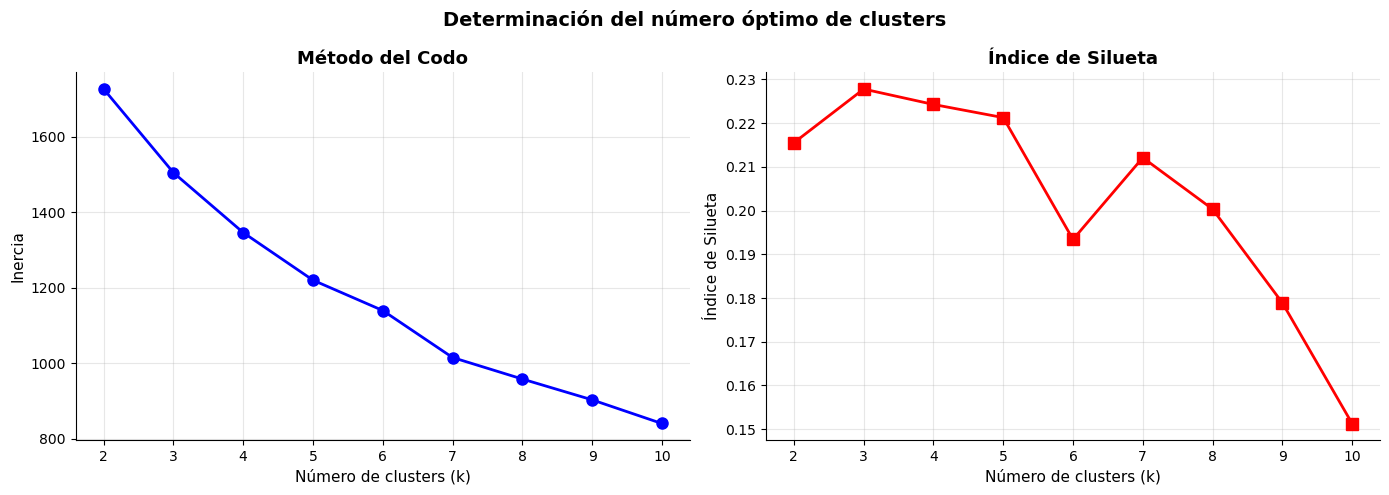

In [4]:
#Número óptimo de clusters

rango_clusters = range(2, 11)
inercias = []
siluetas = []

for k in rango_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f'k={k}: Inercia={kmeans.inertia_:.2f} | Silueta={silhouette_score(X_scaled, kmeans.labels_):.4f}')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
#Método del codo
ax1.plot(rango_clusters, inercias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de clusters (k)', fontsize=11)
ax1.set_ylabel('Inercia', fontsize=11)
ax1.set_title('Método del Codo', fontsize=13, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.3)

#Índice de silueta
ax2.plot(rango_clusters, siluetas, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de clusters (k)', fontsize=11)
ax2.set_ylabel('Índice de Silueta', fontsize=11)
ax2.set_title('Índice de Silueta', fontsize=13, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.3)

plt.suptitle('Determinación del número óptimo de clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + 'optimo_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
#Aplicamos k means con k=3

k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)
df['cluster'] = kmeans_final.labels_

#Vemos distribución de barrios por cluster
print('Distribución de barrios por cluster')
distribucion = df['cluster'].value_counts().sort_index()
for cluster, count in distribucion.items():
    print(f'  Cluster {cluster}: {count} barrios ({count/131*100:.1f}%)')

# Ver qué barrios hay en cada cluster
print('\n=== BARRIOS POR CLUSTER ===')
for c in range(k_optimo):
    print(f'\nCLUSTER {c}:')
    barrios = df[df['cluster'] == c]['barrio'].tolist()
    for b in barrios:
        print(f'  {b}')

Distribución de barrios por cluster
  Cluster 0: 20 barrios (15.3%)
  Cluster 1: 49 barrios (37.4%)
  Cluster 2: 62 barrios (47.3%)

=== BARRIOS POR CLUSTER ===

CLUSTER 0:
  011. Palacio
  012. Embajadores
  013. Cortes
  014. Justicia
  015. Universidad
  016. Sol
  027. Atocha
  034. Ibiza
  035. Los Jerónimos
  041. Recoletos
  042. Goya
  045. Lista
  046. Castellana
  062. Cuatro Caminos
  071. Gaztambide
  072. Arapiles
  073. Trafalgar
  074. Almagro
  075. Ríos Rosas
  092. Argüelles

CLUSTER 1:
  061. Bellas Vistas
  064. Almenara
  065. Valdeacederas
  066. Berruguete
  101. Los Cármenes
  102. Puerta del Ángel
  103. Lucero
  104. Aluche
  105. Campamento
  107. Águilas
  111. Comillas
  112. Opañel
  113. San Isidro
  114. Vista Alegre
  115. Puerta Bonita
  116. Buenavista
  117. Abrantes
  121. Orcasitas
  122. Orcasur
  123. San Fermín
  124. Almendrales
  125. Moscardó
  126. Zofío
  127. Pradolongo
  131. Entrevías
  132. San Diego
  133. Palomeras Bajas
  134. Palome

Perfil medio de cada cluster
cluster                         0       1        2
pct_extranjera              19.68   22.09    10.67
pct_65mas                   21.09   18.24    21.23
pct_pob_2044                38.77   35.14    30.47
pct_extranjera_2044         12.84   12.62     5.81
var_extranjera_1823          4.84    5.37     2.08
var_65mas_1823               0.03   -1.18     1.29
var_pob_2044_1823            0.98    0.39    -1.50
var_extranjera_2044_1823     3.16    2.86     0.96
pct_hosteleria_2023         27.65   18.81    23.42
pct_servicios_prof           3.07    4.17     4.70
pct_comercio_tradicional    50.97   52.71    46.08
pct_inmobiliario             0.96    1.34     1.27
var_hosteleria_1823          1.15    0.89    -0.00
alquiler_2023               20.41   13.46    14.75
catastral_m2              1601.11  784.82  1204.13
var_alquiler_dist_1823      13.96   21.02    15.13
var_catastral_m2_2023       -0.09    0.41    -0.20


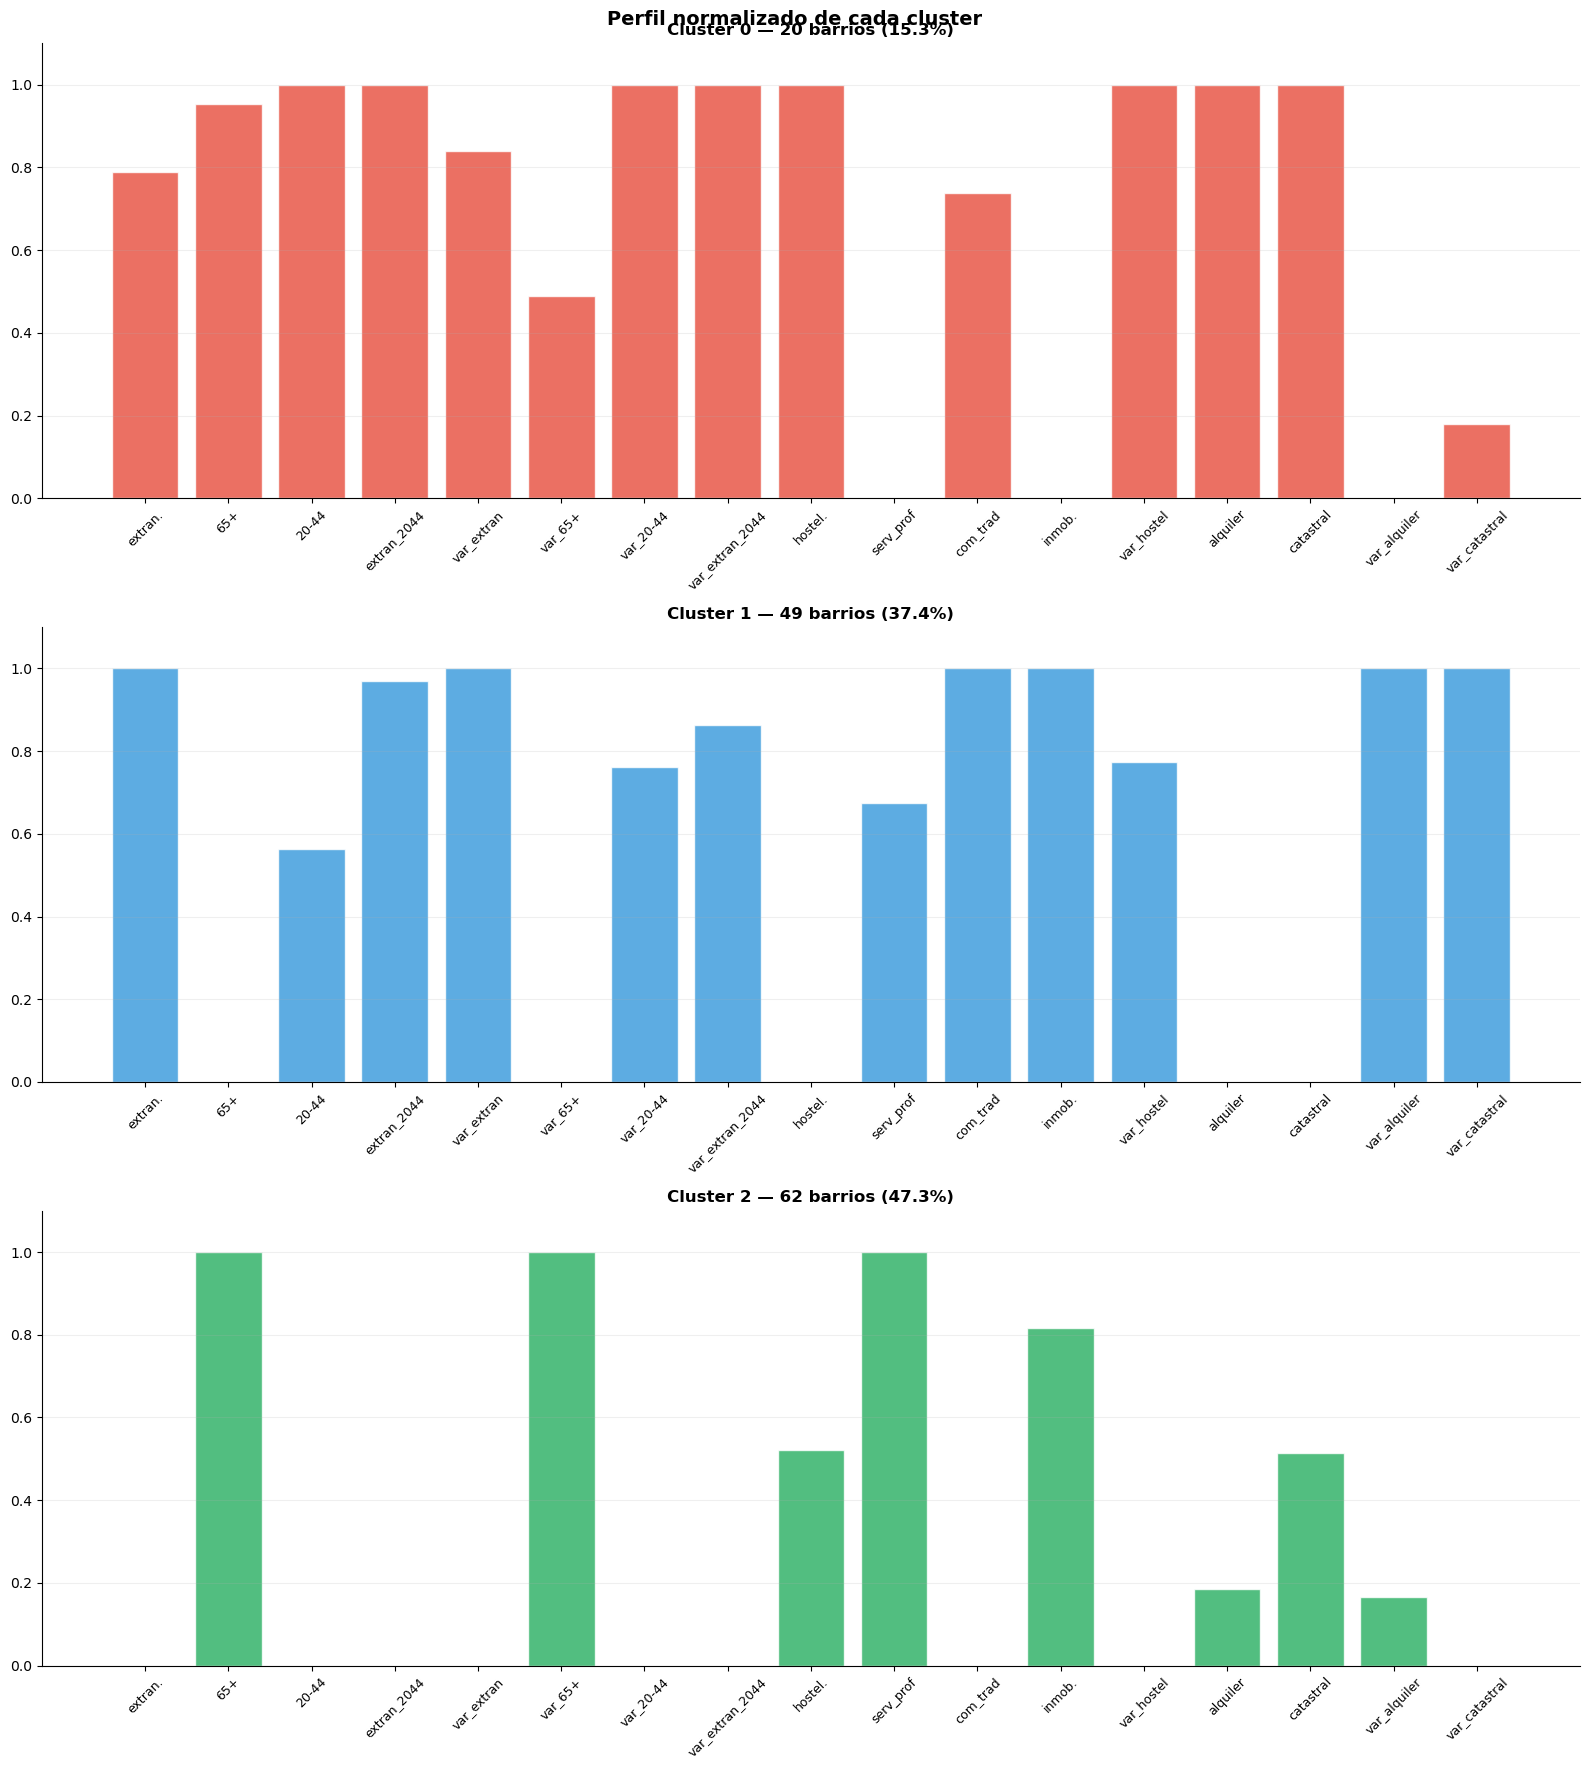

In [6]:
#Caracterización de los cluster

#Media de cada variable por cluster
perfil_clusters = df.groupby('cluster')[variables_clustering].mean().round(2)

print('Perfil medio de cada cluster')
print(perfil_clusters.T.to_string())

#Gráfico de barras comparativas
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

colores_cluster = {0: '#E74C3C', 1: '#3498DB', 2: '#27AE60'}
nombres_cluster = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for c in range(k_optimo):
    datos_cluster = perfil_clusters.loc[c]
    
    #Normalizamos para comparar visualmente
    datos_norm = (datos_cluster - perfil_clusters.min()) / (perfil_clusters.max() - perfil_clusters.min())
    
    etiquetas_cortas = [
        'extran.', '65+', '20-44', 'extran_2044',
        'var_extran', 'var_65+', 'var_20-44', 'var_extran_2044',
        'hostel.', 'serv_prof', 'com_trad', 'inmob.',
        'var_hostel', 'alquiler', 'catastral',
        'var_alquiler', 'var_catastral']
    
    bars = axes[c].bar(
        etiquetas_cortas, 
        datos_norm,
        color=colores_cluster[c],
        alpha=0.8,
        edgecolor='white')
    
    axes[c].set_title(
        f'{nombres_cluster[c]} — {distribucion[c]} barrios ({distribucion[c]/131*100:.1f}%)',
        fontsize=12, fontweight='bold')
    axes[c].set_ylim(0, 1.1)
    axes[c].spines['top'].set_visible(False)
    axes[c].spines['right'].set_visible(False)
    axes[c].tick_params(axis='x', rotation=45, labelsize=9)
    axes[c].grid(True, alpha=0.2, axis='y')

plt.suptitle('Perfil normalizado de cada cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + 'perfil_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
#Asignamos nombres a los cluster

nombres_descriptivos = {
    0: 'Barrios consolidados y turísticos',
    1: 'Barrios en transformación',
    2: 'Barrios residenciales estables'}

df['cluster_nombre'] = df['cluster'].map(nombres_descriptivos)

#Tabla resumen para la memoria
print('Tabla resumen de clusters')
for c in range(k_optimo):
    barrios_cluster = df[df['cluster'] == c]
    print(f'\n{nombres_descriptivos[c]} (Cluster {c}) — {len(barrios_cluster)} barrios')
    print(f'  Alquiler medio 2023:        {barrios_cluster["alquiler_2023"].mean():.2f} €/m²')
    print(f'  Catastral medio:            {barrios_cluster["catastral_m2"].mean():.0f} €/m²')
    print(f'  % Población extranjera:     {barrios_cluster["pct_extranjera"].mean():.2f}%')
    print(f'  % Hostelería y ocio:        {barrios_cluster["pct_hosteleria_2023"].mean():.2f}%')
    print(f'  % Población 20-44 años:     {barrios_cluster["pct_pob_2044"].mean():.2f}%')
    print(f'  Var. alquiler 2018-2023:    {barrios_cluster["var_alquiler_dist_1823"].mean():.2f}%')
    print(f'  Var. hostelería 2018-2023:  {barrios_cluster["var_hosteleria_1823"].mean():.2f} pp')

df.to_csv(FINAL + 'dataset_barrios_clusters.csv', index=False)

Tabla resumen de clusters

Barrios consolidados y turísticos (Cluster 0) — 20 barrios
  Alquiler medio 2023:        20.41 €/m²
  Catastral medio:            1601 €/m²
  % Población extranjera:     19.68%
  % Hostelería y ocio:        27.65%
  % Población 20-44 años:     38.77%
  Var. alquiler 2018-2023:    13.96%
  Var. hostelería 2018-2023:  1.15 pp

Barrios en transformación (Cluster 1) — 49 barrios
  Alquiler medio 2023:        13.46 €/m²
  Catastral medio:            785 €/m²
  % Población extranjera:     22.09%
  % Hostelería y ocio:        18.81%
  % Población 20-44 años:     35.14%
  Var. alquiler 2018-2023:    21.02%
  Var. hostelería 2018-2023:  0.89 pp

Barrios residenciales estables (Cluster 2) — 62 barrios
  Alquiler medio 2023:        14.75 €/m²
  Catastral medio:            1204 €/m²
  % Población extranjera:     10.67%
  % Hostelería y ocio:        23.42%
  % Población 20-44 años:     30.47%
  Var. alquiler 2018-2023:    15.13%
  Var. hostelería 2018-2023:  -0.00 pp


Varianza explicada por PC1: 31.7%
Varianza explicada por PC2: 15.7%
Varianza total explicada:   47.4%


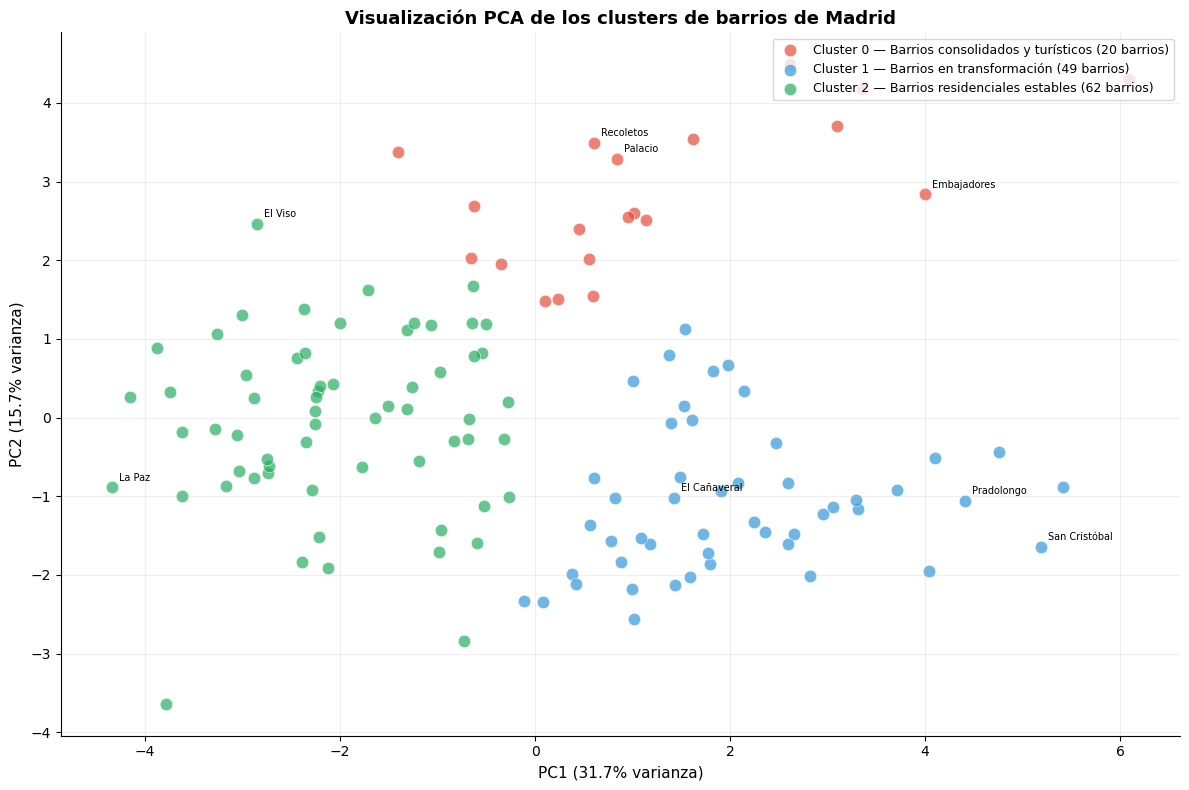

In [8]:
#PCA

#Reducimos a 2 dimensiones para visualizar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza_explicada[0]*100:.1f}%')
print(f'Varianza explicada por PC2: {varianza_explicada[1]*100:.1f}%')
print(f'Varianza total explicada:   {sum(varianza_explicada)*100:.1f}%')

#Gráfico PCA
fig, ax = plt.subplots(figsize=(12, 8))
colores_cluster = {0: '#E74C3C', 1: '#3498DB', 2: '#27AE60'}

for c in range(k_optimo):
    mask = df['cluster'] == c
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1],
        c=colores_cluster[c],
        label=f'Cluster {c} — {nombres_descriptivos[c]} ({distribucion[c]} barrios)',
        alpha=0.7,
        s=80,
        edgecolors='white',
        linewidth=0.5)

#Añadimos etiquetas a barrios destacados
barrios_destacados = [
    '011. Palacio', '012. Embajadores', '041. Recoletos',
    '127. Pradolongo', '172. San Cristóbal', '194. El Cañaveral',
    '085. La Paz', '051. El Viso']

for _, row in df[df['barrio'].isin(barrios_destacados)].iterrows():
    idx = df.index.get_loc(_)
    nombre_corto = row['barrio'].split('. ', 1)[1]
    ax.annotate(
        nombre_corto,
        (X_pca[idx, 0], X_pca[idx, 1]),
        fontsize=7,
        xytext=(5, 5),
        textcoords='offset points')

ax.set_xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Visualización PCA de los clusters de barrios de Madrid', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURES + 'pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

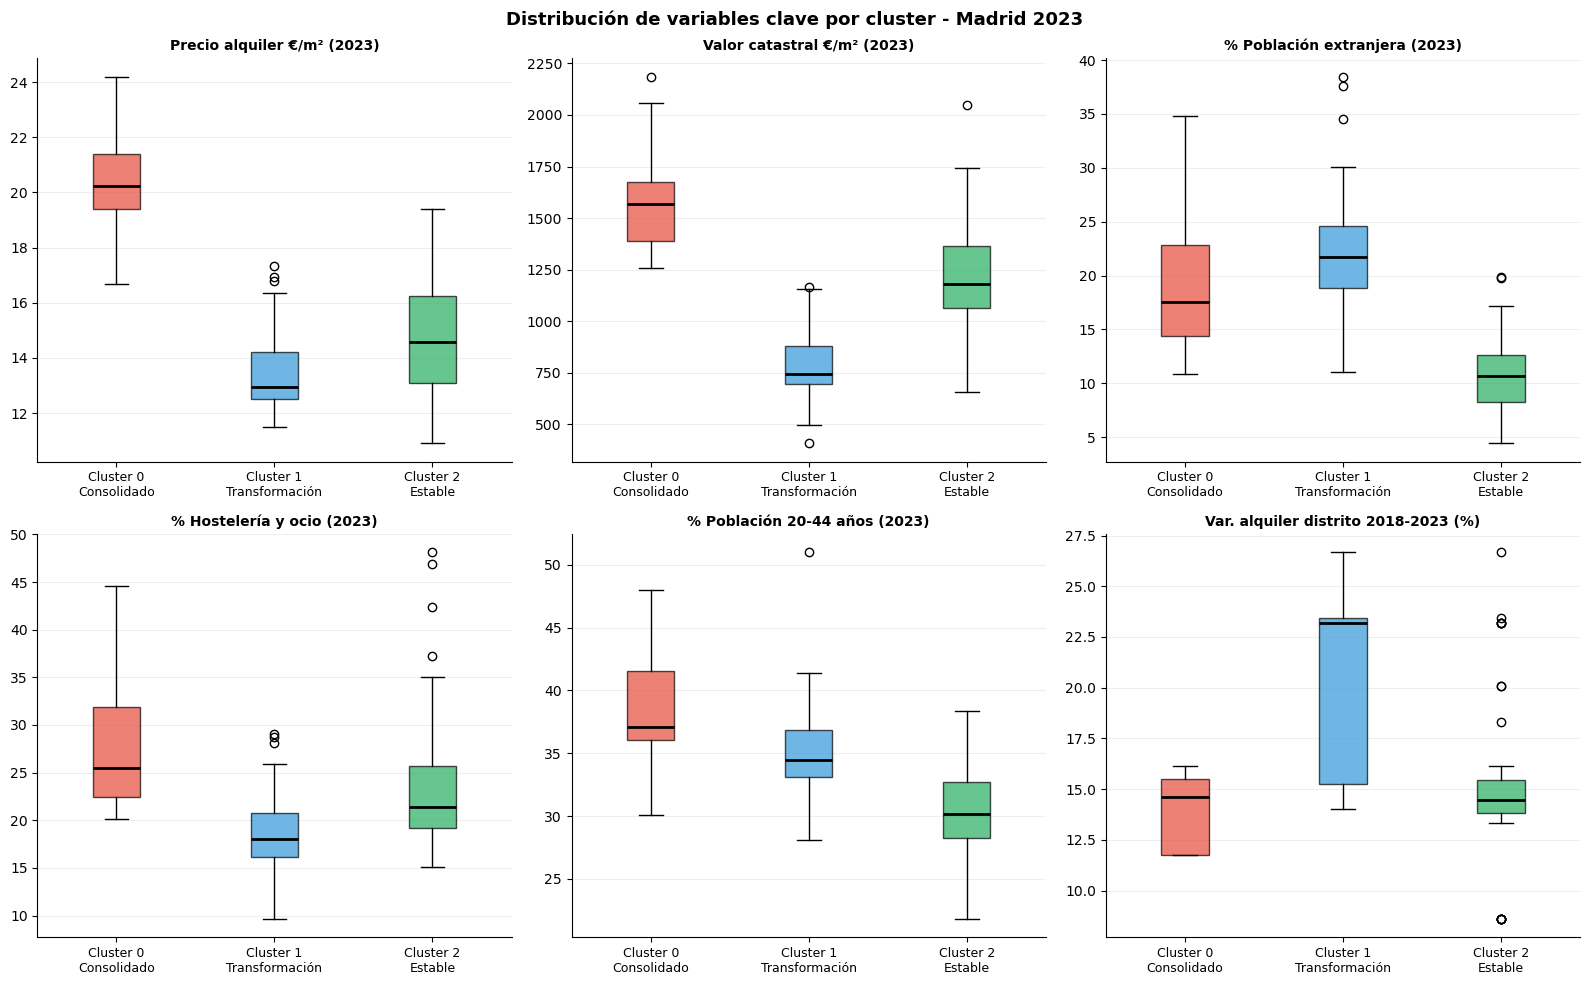

In [9]:
#Bloxplots comparativos por cluster

variables_boxplot = {
    'alquiler_2023': 'Precio alquiler €/m² (2023)',
    'catastral_m2': 'Valor catastral €/m² (2023)',
    'pct_extranjera': '% Población extranjera (2023)',
    'pct_hosteleria_2023': '% Hostelería y ocio (2023)',
    'pct_pob_2044': '% Población 20-44 años (2023)',
    'var_alquiler_dist_1823': 'Var. alquiler distrito 2018-2023 (%)'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colores_box = ['#E74C3C', '#3498DB', '#27AE60']
etiquetas_box = ['Cluster 0\nConsolidado', 'Cluster 1\nTransformación', 'Cluster 2\nEstable']

for i, (variable, titulo) in enumerate(variables_boxplot.items()):
    datos_por_cluster = [
        df[df['cluster'] == c][variable].values 
        for c in range(k_optimo)]
    
    bp = axes[i].boxplot(
        datos_por_cluster,
        patch_artist=True,
        labels=etiquetas_box,
        medianprops={'color': 'black', 'linewidth': 2})
    
    for patch, color in zip(bp['boxes'], colores_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[i].set_title(titulo, fontsize=10, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(True, alpha=0.2, axis='y')
    axes[i].tick_params(axis='x', labelsize=9)

plt.suptitle('Distribución de variables clave por cluster - Madrid 2023', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + 'boxplots_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#Tabla completa de barrios con su cluster
tabla_resultados = df[[
    'cod_barrio', 'barrio', 'cluster', 'cluster_nombre',
    'alquiler_2023', 'catastral_m2', 'pct_extranjera',
    'pct_hosteleria_2023', 'pct_pob_2044', 'var_alquiler_dist_1823'
]].sort_values(['cluster', 'barrio'])

tabla_resultados.to_csv(TABLES + 'resultados_clustering.csv', index=False)

#Resumen
print(f'\nAlgoritmo: K-Means')
print(f'Número de clusters: {k_optimo}')
print(f'Variables utilizadas: {len(variables_clustering)}')
print(f'Barrios analizados: {len(df)}')
print(f'Índice de Silueta (k=3): {siluetas[1]:.4f}')
print(f'Varianza explicada PCA (2 componentes): {sum(varianza_explicada)*100:.1f}%')

print(f'\nDistribución final:')
for c in range(k_optimo):
    print(f'  Cluster {c} - {nombres_descriptivos[c]}: {distribucion[c]} barrios ({distribucion[c]/131*100:.1f}%)')


Algoritmo: K-Means
Número de clusters: 3
Variables utilizadas: 17
Barrios analizados: 131
Índice de Silueta (k=3): 0.2278
Varianza explicada PCA (2 componentes): 47.4%

Distribución final:
  Cluster 0 - Barrios consolidados y turísticos: 20 barrios (15.3%)
  Cluster 1 - Barrios en transformación: 49 barrios (37.4%)
  Cluster 2 - Barrios residenciales estables: 62 barrios (47.3%)


In [11]:
#Analisis desbalanceo cluster
df_clusters = pd.read_csv(FINAL + 'dataset_barrios_clusters.csv')

#Distribución de clusters
total = len(df_clusters)
dist = df_clusters['cluster'].value_counts().sort_index()

#Métricas de desbalanceo
max_clase = dist.max()
min_clase = dist.min()
ratio = max_clase / min_clase

print(f'Clase mayoritaria: {max_clase} barrios')
print(f'Clase minoritaria: {min_clase} barrios')
print(f'Ratio desbalanceo: {ratio:.2f}')

Clase mayoritaria: 62 barrios
Clase minoritaria: 20 barrios
Ratio desbalanceo: 3.10


In [13]:
#Clustering para diferentes K
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    
    dist_k = pd.Series(labels).value_counts().sort_index()
    dist_str = ' | '.join([f'C{i}:{v}' for i, v in dist_k.items()])
    ratio_k = dist_k.max() / dist_k.min()
    
    print(f'{k:<5} {sil:<12.4f} {dist_str:<50} {ratio_k:.2f}')

3     0.2278       C0:20 | C1:49 | C2:62                              3.10
4     0.2243       C0:47 | C1:19 | C2:45 | C3:20                      2.47
5     0.2213       C0:20 | C1:47 | C2:45 | C3:1 | C4:18               47.00
